In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# ケーススタディ: Bruco と ICA によるノイズ削減

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_bruco_ica_denoising.ipynb)

このノートブックでは、実際の干渉計コミッショニングで使われる **エンドツーエンドのノイズ削減ワークフロー** を示します：

1. **Bruco** — ブルートフォースコヒーレンス スキャンで最相関の補助チャンネルを特定
2. **ICA** — 独立成分分析でノイズ源を分離
3. **ノイズ差し引き** — DARM からノイズ寄与を除去し、ASD を比較

これは O4b コミッショニング（DARM 116 Hz ライン調査など）で使われたワークフローを再現しています。
物理的な狙いは、「どのセンサに線が見えるか」から一歩進んで、「どの潜在ノイズ源なら DARM から差し引いても他の構造を壊さないか」を判断することです。

> **前提知識**：
> - [Bruco チュートリアル](advanced_bruco.ipynb) — Bruco の基礎
> - [PCA/ICA チュートリアル](advanced_decomposition.ipynb) — 分解手法の基礎


## セットアップ

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # ruff: noqa: I001
    import matplotlib.pyplot as plt
    import numpy as np
    from astropy import units as u

    from gwexpy.analysis import Bruco
    from gwexpy.timeseries import TimeSeries, TimeSeriesDict, TimeSeriesMatrix


## 1. モックデータの生成

DARM チャンネルに以下が混入するシナリオをシミュレートします：
- 広帯域ガウスノイズ（バックグラウンド雑音フロア）
- 環境センサーから漏れた 116 Hz ラインノイズ

4 つの PEM（Physical Environment Monitor）補助チャンネルは、それぞれ異なる割合で同じ 116 Hz ラインを含みます。
これは O4b コミッショニングの実際のケースを模倣しています。


In [3]:
rng = np.random.default_rng(42)

fs = 512        # sample rate [Hz]
T  = 64.0       # duration [s]
n  = int(fs * T)
t  = np.arange(n) / fs

FREQ_LINE = 116.0  # Hz — the line noise we want to remove

# ----- Independent sources -----
src_line  = np.sin(2 * np.pi * FREQ_LINE * t)   # coherent line noise
src_broad = rng.normal(0, 1, n)                  # broadband floor noise

# ----- DARM: broadband + line leakage -----
DARM_LINE_COUPLING = 0.5
darm_noise = src_broad + DARM_LINE_COUPLING * src_line

target = TimeSeries(
    darm_noise, dt=1 / fs, unit=u.dimensionless_unscaled,
    name="K1:CAL-CS_PROC_DARM_STRAIN_DBL_DQ", t0=0,
)

# ----- 4 auxiliary channels (different line content) -----
aux_configs = {
    "K1:PEM-ACC_PSL_TABLE_PSL1_Y": (0.9, 0.1),  # 90% line, 10% noise
    "K1:PEM-ACC_PSL_TABLE_PSL2_X": (0.7, 0.3),
    "K1:PEM-MIC_PSL_TABLE_PSL1_Z": (0.5, 0.5),
    "K1:PEM-MIC_PSL_TABLE_PSL2_Z": (0.2, 0.8),  # mostly noise
}

aux_dict = TimeSeriesDict({
    name: TimeSeries(
        a_line * src_line + a_noise * rng.normal(0, 1, n),
        dt=1 / fs, unit=u.dimensionless_unscaled, name=name, t0=0,
    )
    for name, (a_line, a_noise) in aux_configs.items()
        })

print(f"DARM   sample rate: {target.sample_rate}")
print(f"Aux channels: {list(aux_dict.keys())}")


DARM   sample rate: 512.0 Hz
Aux channels: ['K1:PEM-ACC_PSL_TABLE_PSL1_Y', 'K1:PEM-ACC_PSL_TABLE_PSL2_X', 'K1:PEM-MIC_PSL_TABLE_PSL1_Z', 'K1:PEM-MIC_PSL_TABLE_PSL2_Z']


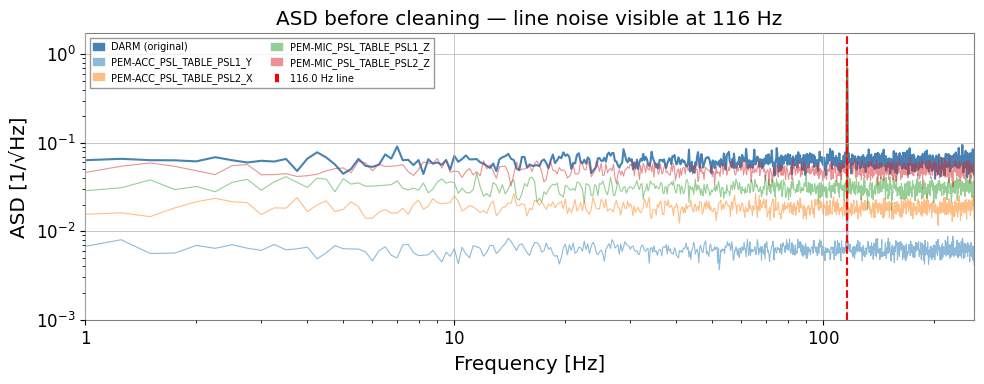

In [4]:
# Visualize the line noise in the ASD before cleaning
fig, ax = plt.subplots(figsize=(10, 4))
asd = target.asd(fftlength=4, overlap=2)
ax.loglog(asd.frequencies.value, asd.value, label="DARM (original)", color="steelblue")

for name, ts in aux_dict.items():
    a = ts.asd(fftlength=4, overlap=2)
    ax.loglog(a.frequencies.value, a.value, alpha=0.5, lw=0.8, label=name.split(":")[-1])

ax.axvline(FREQ_LINE, color="red", ls="--", label=f"{FREQ_LINE} Hz line")
ax.set_xlim(1, fs / 2)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [1/√Hz]")
ax.set_title("ASD before cleaning — line noise visible at 116 Hz")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


## 2. Bruco: 相関補助チャンネルの特定

`Bruco.compute()` は全補助チャンネルをスキャンし、各周波数ビンで上位 *N* 件の最相関チャンネルを返します。
これがパイプラインの **第 1 ステージ** です：DARM と同じノイズを観測しているセンサーを特定します。

> **よくある誤り**: 使える補助チャンネルをすべて ICA に投入すること。ここでの Bruco は、116 Hz 汚染を本当に共有していそうなチャンネルへ絞るための物理フィルタです。


In [5]:
bruco = Bruco(target_channel=target.name, aux_channels=[])

result = bruco.compute(
    fftlength=4.0,
    overlap=2.0,
    target_data=target,
    aux_data=aux_dict,
    top_n=4,         # keep top-4 channels per frequency bin
)

print("Bruco scan complete.")
print(f"Result type: {type(result)}")


Bruco scan complete.
Result type: <class 'gwexpy.analysis.bruco.BrucoResult'>


In [6]:
# Show top channels near the 116 Hz line
df = result.to_dataframe(ranks=[0])
df_line = (
    df[df["frequency"].between(114, 118)]
    .sort_values("coherence", ascending=False)
    .dropna(subset=["channel"])
    .head(10)
    .reset_index(drop=True)
)
print("Top correlated channels near 116 Hz:")
df_line


Top correlated channels near 116 Hz:


,frequency,rank,channel,coherence,projection
0,116.00,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.995049,0.696766
1,115.75,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.984059,0.334223
2,116.25,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.979161,0.333768
3,114.75,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.459202,0.029435
4,116.75,1,K1:PEM-ACC_PSL_TABLE_PSL2_X,0.403842,0.024020
5,115.00,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.330589,0.020492
6,117.00,1,K1:PEM-ACC_PSL_TABLE_PSL2_X,0.293278,0.020808
7,117.50,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.271092,0.016356
8,114.50,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.269835,0.020907
9,115.50,1,K1:PEM-MIC_PSL_TABLE_PSL1_Z,0.246493,0.014666


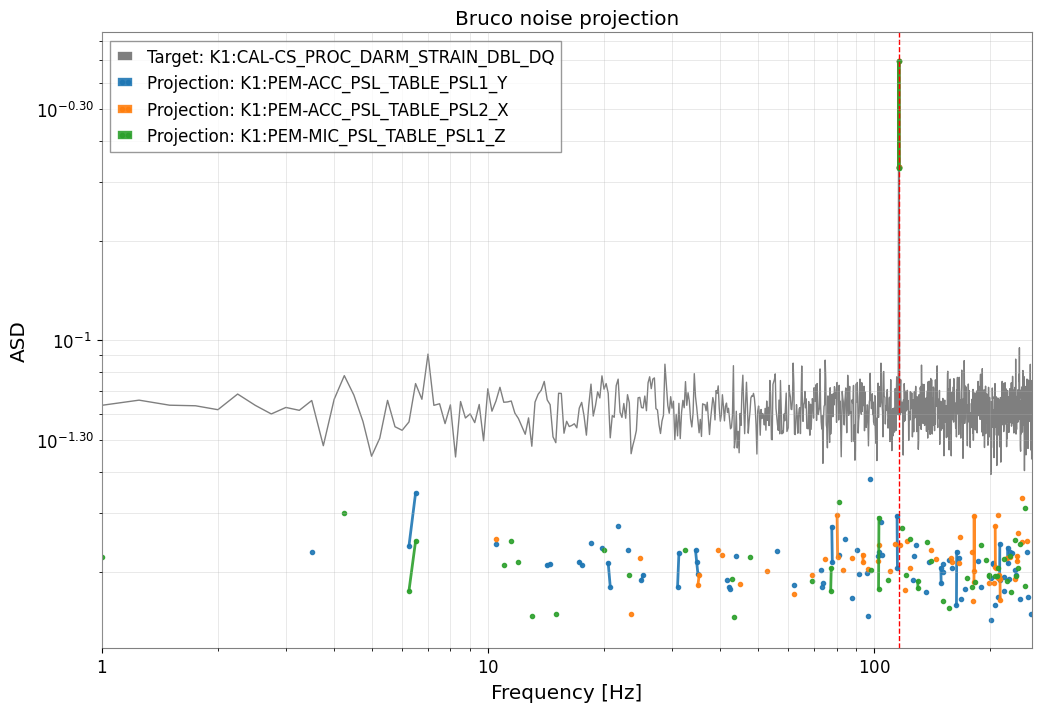

In [7]:
# Coherence projection plot — shows which channels dominate at each frequency
result.plot_projection(coherence_threshold=0.3)
plt.xlim(1, fs / 2)
plt.axvline(FREQ_LINE, color="red", ls="--", lw=1)
plt.title("Bruco noise projection")
plt.show()


## 3. ICA: ノイズ源の分離

Bruco スキャンから、DARM と 116 Hz 付近で高いコヒーレンスを持つチャンネルが分かりました。
次にこれらのチャンネルを `TimeSeriesMatrix` に積み上げ、**ICA** を適用して
独立したノイズ源を分離します。

ICA モデルは混合行列 **A** を求めます：
```
X = S · A^T   （X: 観測チャンネル、S: 独立成分）
```
この行列を使って DARM からノイズ成分の寄与を差し引けます。

> **注意したい失敗モード**: ICA 成分は物理的重要度順には並ばず、符号やスケールも任意です。どの成分が狙いの 116 Hz ラインに対応するかは、ASD と各チャンネルへの荷重を必ず見てから判断してください。


> **注意 — ICA の収束**: データによっては FastICA がデフォルトのイテレーション数内で収束しない場合があります。`ConvergenceWarning` が表示された場合は、ICA パラメータの `max_iter` や `tol` の調整を検討してください。完全に収束しなくても結果が利用できる場合があります。
>
> もう一つの典型的な失敗は rank deficiency です。ほぼ同一のウィットネスばかりを入れると分解が不安定になり、差し引き係数を信頼しにくくなります。完全に冗長ではないが情報量のある少数チャンネルを選んでください。


In [8]:
# Pick the top-2 channels from Bruco result
TOP_CHANNELS = df_line["channel"].dropna().unique()[:2].tolist()
print("Selected channels for ICA:", TOP_CHANNELS)

# Stack DARM + top channels into a TimeSeriesMatrix  (shape: n_ch × 1 × n_samples)
channels = [target] + [aux_dict[ch] for ch in TOP_CHANNELS]
data_3d = np.stack([ch.value for ch in channels], axis=0)[:, np.newaxis, :]

tsm = TimeSeriesMatrix(
    data_3d, dt=1 / fs, unit=u.dimensionless_unscaled, t0=0,
)
print(f"TimeSeriesMatrix shape: {tsm.shape}  (n_channels × 1 × n_samples)")


Selected channels for ICA: ['K1:PEM-ACC_PSL_TABLE_PSL1_Y', 'K1:PEM-ACC_PSL_TABLE_PSL2_X']
TimeSeriesMatrix shape: (3, 1, 32768)  (n_channels × 1 × n_samples)


ICA stopped after 63 iterations
Mixing matrix A shape: (3, 3)


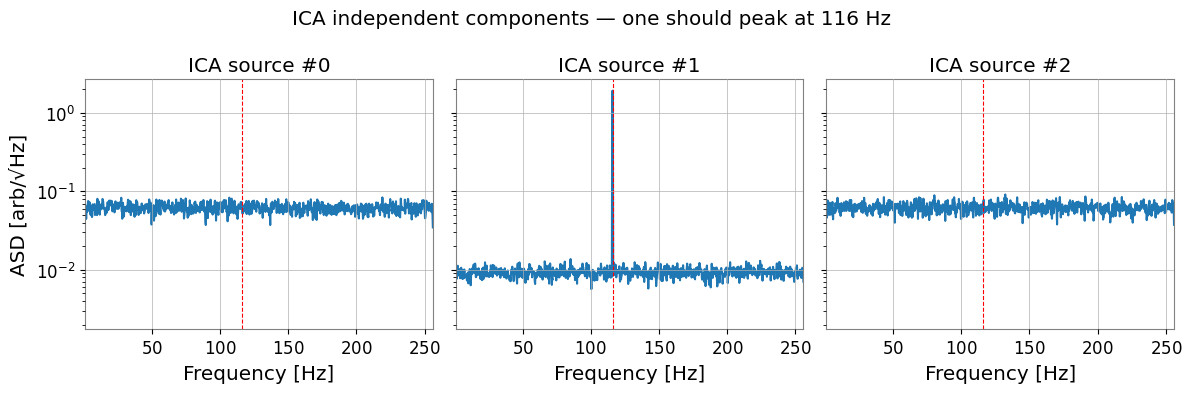

In [9]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # Run ICA
    n_components = len(channels)
    ica_sources, ica_model = tsm.ica(n_components=n_components, return_model=True)

    sk = ica_model.sklearn_model
    print(f"ICA stopped after {sk.n_iter_} iterations")
    print(f"Mixing matrix A shape: {sk.mixing_.shape}")  # (n_channels, n_components)

    # Visualize ICA sources in frequency domain
    fig, axes = plt.subplots(1, n_components, figsize=(4 * n_components, 4), sharey=True)
    for k in range(n_components):
        src_ts = TimeSeries(
            ica_sources.value[k, 0, :], dt=1 / fs,
            unit=u.dimensionless_unscaled, t0=0,
        )
        asd_k = src_ts.asd(fftlength=4, overlap=2)
        axes[k].semilogy(asd_k.frequencies.value, asd_k.value)
        axes[k].axvline(FREQ_LINE, color="red", ls="--", lw=0.8)
        axes[k].set_title(f"ICA source #{k}")
        axes[k].set_xlim(1, fs / 2)
        axes[k].set_xlabel("Frequency [Hz]")

    axes[0].set_ylabel("ASD [arb/√Hz]")
    plt.suptitle("ICA independent components — one should peak at 116 Hz")
    plt.tight_layout()
    plt.show()


## 4. ノイズ差し引きと ASD 比較

116 Hz ラインを含む ICA 成分を特定し（ASD を確認して選択）、
混合行列を使って DARM からその寄与を差し引きます。

```
DARM_clean = DARM - Σ_k  A[0, k] · S_k(t)     （ノイズ成分 k の和）
```

> **よくある誤り**: 非ガウスっぽく見える ICA 成分を全部引くこと。スペクトル形状とウィットネス荷重が狙っている結合機構に一致する成分だけを選ばないと、ライン以外の検出器構造まで削ってしまう危険があります。


In [10]:
# Identify the noise component: the one with the largest ASD at FREQ_LINE
fftlength = 4.0
overlap   = 2.0
freqs = np.fft.rfftfreq(int(fftlength * fs), d=1 / fs)
line_bin = np.argmin(np.abs(freqs - FREQ_LINE))

A = sk.mixing_           # (n_channels, n_components)
X_raw = data_3d[:, 0, :].T   # (n_samples, n_channels)
S = sk.transform(X_raw)       # (n_samples, n_components)

# ASD of each component at the line frequency
asd_at_line = []
for k in range(n_components):
    s_ts = TimeSeries(S[:, k], dt=1 / fs, unit=u.dimensionless_unscaled, t0=0)
    asd_k = s_ts.asd(fftlength=fftlength, overlap=overlap)
    val = float(np.interp(FREQ_LINE, asd_k.frequencies.value, asd_k.value))
    asd_at_line.append(val)

noise_component = int(np.argmax(asd_at_line))
print(f"Dominant noise component: #{noise_component}  (ASD at {FREQ_LINE} Hz = {asd_at_line[noise_component]:.4f})")

# Subtract noise component from DARM (channel index 0)
darm_clean = X_raw[:, 0] - A[0, noise_component] * S[:, noise_component]
target_clean = TimeSeries(
    darm_clean, dt=1 / fs, unit=u.dimensionless_unscaled,
    name="DARM_cleaned", t0=0,
)


Dominant noise component: #1  (ASD at 116.0 Hz = 1.5725)


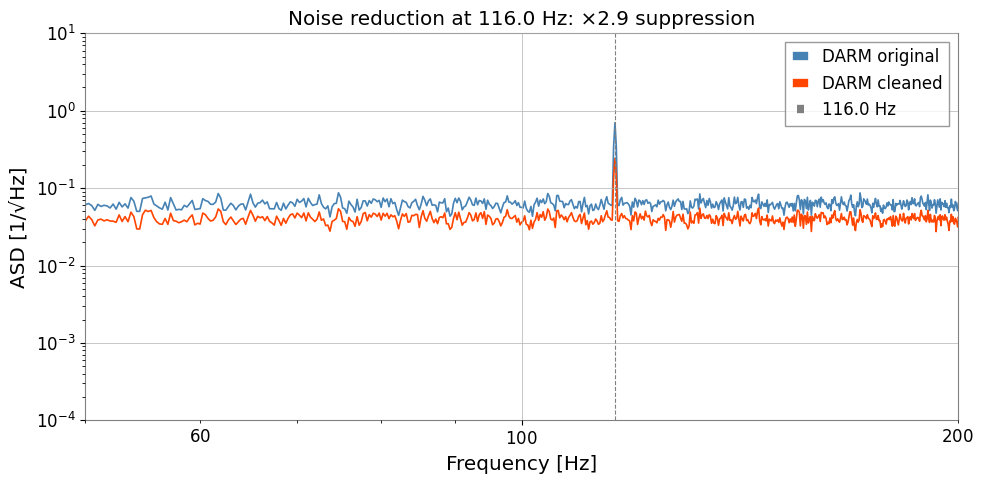

Suppression factor at 116.0 Hz: 2.89×


In [11]:
# Compare original vs cleaned ASD
asd_orig  = target.asd(fftlength=fftlength, overlap=overlap)
asd_clean = target_clean.asd(fftlength=fftlength, overlap=overlap)

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(asd_orig.frequencies.value,  asd_orig.value,  label="DARM original",  color="steelblue", lw=1.2)
ax.loglog(asd_clean.frequencies.value, asd_clean.value, label="DARM cleaned",   color="orangered",  lw=1.2)
ax.axvline(FREQ_LINE, color="gray", ls="--", lw=0.8, label=f"{FREQ_LINE} Hz")

# Suppression factor at line frequency
ratio = float(np.interp(FREQ_LINE, asd_orig.frequencies.value, asd_orig.value)) /         float(np.interp(FREQ_LINE, asd_clean.frequencies.value, asd_clean.value))
ax.set_xlim(50, 200)
ax.set_ylim(1e-4, 10)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [1/√Hz]")
ax.set_title(f"Noise reduction at {FREQ_LINE} Hz: ×{ratio:.1f} suppression")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Suppression factor at {FREQ_LINE} Hz: {ratio:.2f}×")


## まとめ

| ステップ | ツール | 出力 |
|---------|--------|------|
| 1. コヒーレンス スキャン | `Bruco.compute()` | 各周波数での最相関チャンネル |
| 2. ノイズ源分離 | `TimeSeriesMatrix.ica()` | 独立成分 + 混合行列 |
| 3. ノイズ差し引き | 混合行列の代数演算 | クリーン DARM チャンネル |

### ポイント

- **Bruco** が数千チャンネルを効率的に絞り込み、重要な少数チャンネルを特定します。
- **ICA** はコヒーレンスを超えて、複数センサーが共通ノイズを共有する場合でも *独立* な寄与を分離します。
- 混合行列 `A` が、時間領域フィルタリングなしに直接差し引き式を与えます。
- 安定した subtraction は、ICA ソルバそのものよりもウィットネス選定と成分同定に強く依存します。

### 次のステップ

- モックデータを実データ（`TimeSeries.read()` や NDS2）に置き換える。
- より長いセグメントで解析し、Bruco の投影推定と照合する。
- `Spectrogram.normalize()`（SNR スペクトログラム）と組み合わせて、ラインの時間変化を追跡する。
